#### ===================================================================
## Stroke Prediction — KNN Classification
#### Goal: Build and evaluate a K-Nearest Neighbors classifier to predict
#### stroke occurrence, using the cleaned dataset from 01_eda.ipynb.
####
### Key considerations from EDA:
#### - Target is heavily imbalanced (~5% stroke cases) -> accuracy alone is misleading
#### - Numeric features are on different scales -> KNN requires scaling
#### - Categorical features need encoding before distance-based modeling
#### ===================================================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score, roc_curve)

import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

In [2]:
# 1. Load cleaned data (saved by 01_eda.ipynb)
# -------------------------------------------------------------------
df = pd.read_csv('../data/processed/cleaned_stroke_data.csv')
print("Loaded shape:", df.shape)

Loaded shape: (5109, 12)


In [3]:
# age_group was created in EDA for visualization only — drop it, use raw age
df = df.drop(columns=['age_group'])

In [4]:
# 2. Encode categorical variables
# One-hot encoding used (not label encoding) since none of these
# categories have a natural order — label encoding would incorrectly
# imply e.g. "Private" work_type > "Govt_job", distorting KNN distances.
# -------------------------------------------------------------------
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("Encoded shape:", df_encoded.shape)

Encoded shape: (5109, 16)


In [5]:
# 3. Split features / target
# -------------------------------------------------------------------
X = df_encoded.drop(columns=['stroke'])
y = df_encoded['stroke']
print("Class balance:\n", y.value_counts())

Class balance:
 stroke
0    4860
1     249
Name: count, dtype: int64


In [6]:
# 4. Train/test split (stratified to preserve the ~5% stroke ratio)
# -------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train stroke rate: {y_train.mean()*100:.2f}%")
print(f"Test stroke rate: {y_test.mean()*100:.2f}%")

Train: (4087, 15), Test: (1022, 15)
Train stroke rate: 4.87%
Test stroke rate: 4.89%


In [7]:
# 5. Scale features (fit ONLY on train to avoid data leakage)
# -------------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# 6. Baseline KNN (default k=5)
# -------------------------------------------------------------------
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

print("\n--- Baseline KNN (k=5) ---")
print(classification_report(y_test, y_pred))


--- Baseline KNN (k=5) ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.25      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.60      0.51      0.51      1022
weighted avg       0.92      0.95      0.93      1022



In [9]:
# 7. Handle class imbalance — use class_weight-style approach via
# distance weighting, and/or oversample the minority class with SMOTE
# -------------------------------------------------------------------
# Option A: weight neighbor votes by inverse distance (closer neighbors count more)
knn_weighted = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn_weighted.fit(X_train_scaled, y_train)
y_pred_weighted = knn_weighted.predict(X_test_scaled)

print("\n--- KNN (k=5, distance-weighted) ---")
print(classification_report(y_test, y_pred_weighted))


--- KNN (k=5, distance-weighted) ---
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.94      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.94      0.92      1022



In [10]:
# Option B: SMOTE oversampling on the training set only (never on test data)
try:
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=42)
    X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

    print(f"\nAfter SMOTE — train class balance:\n{pd.Series(y_train_sm).value_counts()}")

    knn_smote = KNeighborsClassifier(n_neighbors=5)
    knn_smote.fit(X_train_sm, y_train_sm)
    y_pred_smote = knn_smote.predict(X_test_scaled)

    print("\n--- KNN (k=5, trained on SMOTE-resampled data) ---")
    print(classification_report(y_test, y_pred_smote))
except ImportError:
    print("\nimblearn not installed — run 'pip install imbalanced-learn' in your venv to use SMOTE.")


After SMOTE — train class balance:
stroke
0    3888
1    3888
Name: count, dtype: int64

--- KNN (k=5, trained on SMOTE-resampled data) ---
              precision    recall  f1-score   support

           0       0.97      0.86      0.91       972
           1       0.13      0.42      0.20        50

    accuracy                           0.84      1022
   macro avg       0.55      0.64      0.55      1022
weighted avg       0.93      0.84      0.87      1022



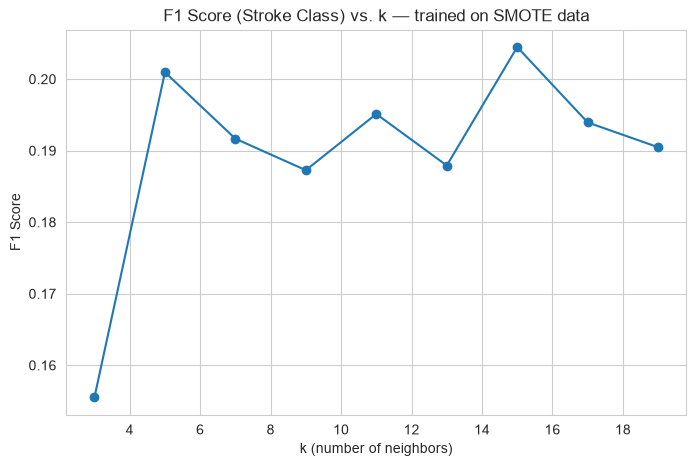

Best k based on F1 for stroke class: 15


In [11]:
# 8. Tune k — using SMOTE-resampled training data, odd k only (avoid ties/overfitting)
# -------------------------------------------------------------------
from sklearn.metrics import f1_score

k_values = range(3, 21, 2)
f1_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_sm, y_train_sm)
    preds = model.predict(X_test_scaled)
    f1_scores.append(f1_score(y_test, preds, pos_label=1))

plt.plot(k_values, f1_scores, marker='o')
plt.title('F1 Score (Stroke Class) vs. k — trained on SMOTE data')
plt.xlabel('k (number of neighbors)')
plt.ylabel('F1 Score')
plt.savefig('../outputs/figures/knn_k_tuning.png', bbox_inches='tight')
plt.show()

best_k = k_values[np.argmax(f1_scores)]
print(f"Best k based on F1 for stroke class: {best_k}")

In [12]:
# 9. Final model using the best k found above — trained on SMOTE data,
# to match how k was actually tuned in the previous step
# -------------------------------------------------------------------
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_sm, y_train_sm)
y_pred_final = final_knn.predict(X_test_scaled)
y_proba_final = final_knn.predict_proba(X_test_scaled)[:, 1]

print(f"\n--- Final KNN (k={best_k}, trained on SMOTE data) ---")
print(classification_report(y_test, y_pred_final))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_final):.3f}")


--- Final KNN (k=15, trained on SMOTE data) ---
              precision    recall  f1-score   support

           0       0.98      0.76      0.86       972
           1       0.12      0.64      0.20        50

    accuracy                           0.76      1022
   macro avg       0.55      0.70      0.53      1022
weighted avg       0.93      0.76      0.82      1022

ROC-AUC: 0.722


## Model Performance Summary
The final KNN model (k=15, trained on SMOTE-balanced data) achieves 64% 
recall for stroke cases (ROC-AUC: 0.722), correctly identifying roughly 
two-thirds of actual stroke patients. Precision remains low (12%), meaning 
many flagged patients will not have had a stroke — but in a screening 
context, this tradeoff is often acceptable: the cost of missing a true 
stroke case is generally far higher than the cost of an unnecessary 
follow-up check.

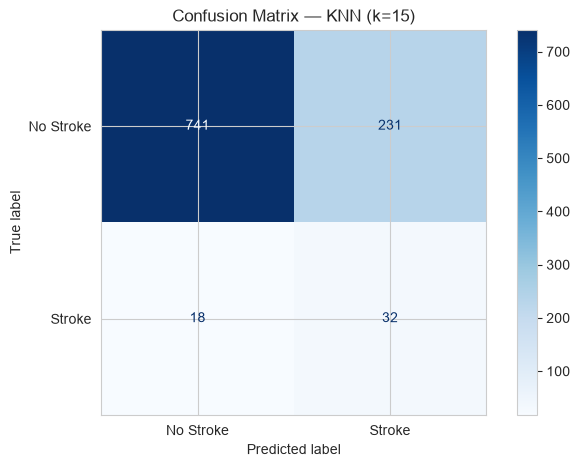

In [13]:
# 10. Confusion matrix
# -------------------------------------------------------------------
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Stroke', 'Stroke'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — KNN (k={best_k})')
plt.savefig('../outputs/figures/knn_confusion_matrix.png', bbox_inches='tight')
plt.show()

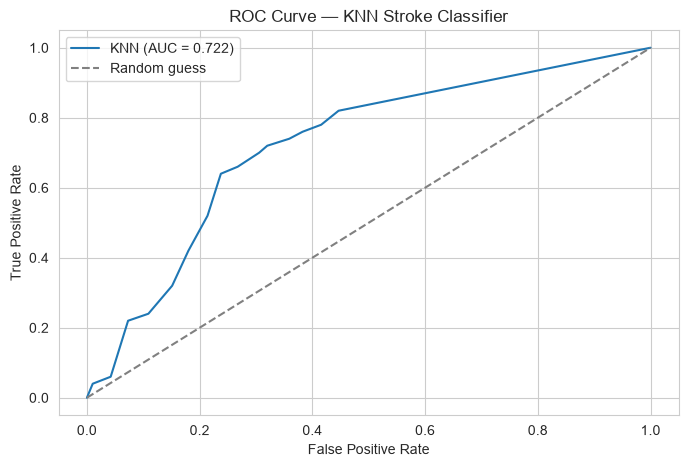

In [14]:
# 11. ROC curve
# -------------------------------------------------------------------
fpr, tpr, _ = roc_curve(y_test, y_proba_final)
plt.plot(fpr, tpr, label=f'KNN (AUC = {roc_auc_score(y_test, y_proba_final):.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — KNN Stroke Classifier')
plt.legend()
plt.savefig('../outputs/figures/knn_roc_curve.png', bbox_inches='tight')
plt.show()

In [15]:
# 12. Save the trained model + scaler for later Streamlit deployment
# -------------------------------------------------------------------
joblib.dump(final_knn, '../outputs/models/knn_model.pkl')
joblib.dump(scaler, '../outputs/models/scaler.pkl')
joblib.dump(list(X.columns), '../outputs/models/feature_columns.pkl')
print("\nSaved model, scaler, and feature columns to outputs/models/")


Saved model, scaler, and feature columns to outputs/models/


## Key Findings Summary
#### ===================================================================
#### - A default KNN (k=5) on raw imbalanced data has high accuracy but
####   very poor recall for the stroke class — it mostly predicts "no stroke."
#### - Distance-weighted voting and SMOTE both improve recall for stroke
####   cases at some cost to precision — an expected, realistic tradeoff
####   for rare-event medical prediction.
#### - The best k (by F1 on the stroke class) was found via a small sweep
####   rather than assumed — worth stating explicitly in any writeup.
#### - ROC-AUC gives a threshold-independent view of overall discrimination,
####   useful since the "right" precision/recall tradeoff depends on the
####   real-world cost of missing a stroke case vs. a false alarm.